<a href="https://colab.research.google.com/github/Miguithub/NPP_Cripto_5min/blob/EDA/EDA_y_Split_11_2024_12_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***APERTURA***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Mounted at /content/drive


In [ ]:
df = pd.read_parquet('/content/drive/MyDrive/Neural/NPP/Cripto/Crypto 5 minutos/112024-122025_clean_add.parquet')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131616 entries, 0 to 131615
Columns: 20918 entries, bar_end to 币安人生__TURNOVER_PER_TRADE_AUDIT
dtypes: datetime64[ns, UTC](1), float32(19897), int8(1020)
memory usage: 9.9 GB


In [ ]:
df.head(5)

,bar_end,0G_y,1000CAT_y,1000CHEEMS_y,1000SATS_y,1INCH_y,1MBABYDOGE_y,2Z_y,A_y,A2Z_y,...,ZBT__TURNOVER_PER_TRADE_AUDIT,ZEC__TURNOVER_PER_TRADE_AUDIT,ZEN__TURNOVER_PER_TRADE_AUDIT,ZIL__TURNOVER_PER_TRADE_AUDIT,ZK__TURNOVER_PER_TRADE_AUDIT,ZKC__TURNOVER_PER_TRADE_AUDIT,ZKP__TURNOVER_PER_TRADE_AUDIT,ZRO__TURNOVER_PER_TRADE_AUDIT,ZRX__TURNOVER_PER_TRADE_AUDIT,币安人生__TURNOVER_PER_TRADE_AUDIT
0,2024-11-01 00:05:00+00:00,0.0,0.0,0.0,51731.433594,3991.891357,33958.218750,0.0,0.0,0.0,...,NaN,248.116989,84.430283,113.005386,158.205627,NaN,NaN,189.143265,110.284966,NaN
1,2024-11-01 00:10:00+00:00,0.0,0.0,0.0,47247.265625,3668.662354,45070.511719,0.0,0.0,0.0,...,NaN,34.487278,10.937200,131.564163,100.164459,NaN,NaN,159.706940,137.513336,NaN
2,2024-11-01 00:15:00+00:00,0.0,0.0,0.0,36383.859375,2242.512939,41139.875000,0.0,0.0,0.0,...,NaN,46.370312,100.915909,185.056900,98.921486,NaN,NaN,143.361298,111.905540,NaN
3,2024-11-01 00:20:00+00:00,0.0,0.0,0.0,13662.238281,1834.763306,14008.003906,0.0,0.0,0.0,...,NaN,98.037308,144.916122,318.255676,130.942841,NaN,NaN,188.986923,250.174393,NaN
4,2024-11-01 00:25:00+00:00,0.0,0.0,0.0,26188.800781,155.050949,21522.748047,0.0,0.0,0.0,...,NaN,78.181824,158.270050,116.318573,33.208981,NaN,NaN,199.042877,96.348557,NaN


#Macro analisis
Se toman maximos, minimos, medias y el dato inicial por intervalos de 6 horas para analizar la tendencia, estacionalidad y quiebres estructurales


In [ ]:
cols = [c for c in df.columns if c.endswith(("_yp", "USDT"))]

dfmacro = (
    df.set_index("bar_end")[cols]
      .resample("6h")
      .agg(["mean", "max", "min"])
)

dfmacro.columns = [f"{c}_{stat}" for c, stat in dfmacro.columns]
dfmacro = dfmacro.reset_index()

In [ ]:
dfmacro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1829 entries, 0 to 1828
Columns: 3061 entries, bar_end to UNFI_yp_min
dtypes: datetime64[ns, UTC](1), float32(3060)
memory usage: 21.4 MB


## datos a analizar:
 112024-122025_macro_add1

In [ ]:
ruta = "/content/drive/MyDrive/Neural/NPP/Cripto/Crypto 5 minutos/"

archivo_salida = ruta + "112024-122025_macro_add1.parquet"

dfmacro.to_parquet(archivo_salida, index=False)

print(f"Guardado en: {archivo_salida}")

Guardado en: /content/drive/MyDrive/Neural/NPP/Cripto/Crypto 5 minutos/112024-122025_macro_add1.parquet


***APERTURA***

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Mounted at /content/drive


In [2]:
dfmacro = pd.read_parquet('/content/drive/MyDrive/Neural/NPP/Cripto/Crypto 5 minutos/112024-122025_macro_add1.parquet')

In [5]:
dfmacro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1829 entries, 0 to 1828
Columns: 3061 entries, bar_end to UNFI_yp_min
dtypes: datetime64[ns, UTC](1), float32(3060)
memory usage: 21.4 MB


##Análisis Exploratorio Inicial de la Estructura Transaccional

En esta sección se analiza la distribución transversal del valor medio de las variables terminadas en _yp, calculadas a partir de intervalos agregados de seis horas. Para cada variable se obtiene su media temporal y, posteriormente, se estudia cómo se distribuyen estos valores entre los distintos activos o entidades considerados.

El análisis incluye un histograma de frecuencias y un conjunto de estadísticos descriptivos: media, mediana, moda, varianza, desviación estándar, sesgo, curtosis, rango intercuartílico, cuartiles y percentiles. Estos indicadores permiten caracterizar la tendencia central, dispersión, asimetría, concentración y presencia de valores extremos en la distribución.

El objetivo es identificar cómo se reparte, en promedio, la participación probabilística entre las distintas variables _yp, determinando si la distribución se encuentra relativamente homogénea o si, por el contrario, presenta una fuerte concentración en un grupo reducido de activos.

In [ ]:
top10 = (
    dfmacro.filter(regex=r"_yp_mean$")
           .mean()
           .nlargest(20)
           .reset_index()
)

top10.columns = ["variable", "mean"]
top10

,variable,mean
0,BTC_yp_mean,0.164137
1,ETH_yp_mean,0.126208
2,USDC_yp_mean,0.111296
3,SOL_yp_mean,0.055698
4,XRP_yp_mean,0.040472
5,FDUSD_yp_mean,0.035064
6,DOGE_yp_mean,0.025772
7,BNB_yp_mean,0.020459
8,PEPE_yp_mean,0.016692
9,SUI_yp_mean,0.015872


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

yp = dfmacro.filter(regex=r"_yp_mean$").mean().dropna()

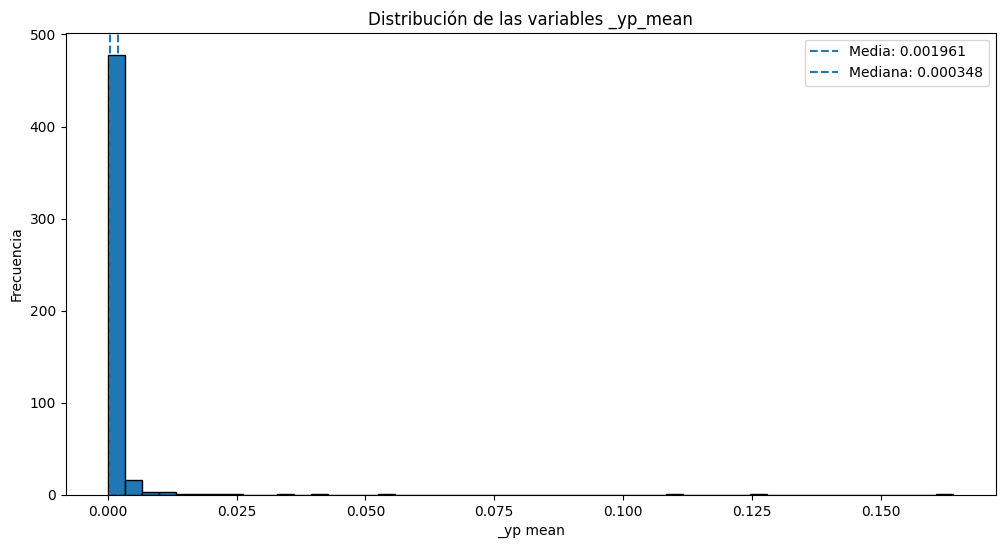

In [ ]:
plt.figure(figsize=(12, 6))
plt.hist(yp, bins=50, edgecolor="black")
plt.axvline(yp.mean(), linestyle="--", label=f"Media: {yp.mean():.6f}")
plt.axvline(yp.median(), linestyle="--", label=f"Mediana: {yp.median():.6f}")
plt.xlabel("_yp mean")
plt.ylabel("Frecuencia")
plt.title("Distribución de las variables _yp_mean")
plt.legend()
plt.show()

In [ ]:
q = yp.quantile([0.25, 0.50, 0.75])

estadisticas = pd.Series({
    "n": yp.size,
    "media": yp.mean(),
    "mediana": yp.median(),
    "moda": yp.mode().iloc[0],
    "varianza": yp.var(),
    "desviacion_estandar": yp.std(),
    "sesgo": yp.skew(),
    "kurtosis": yp.kurt(),
    "minimo": yp.min(),
    "Q1": q[0.25],
    "Q2_mediana": q[0.50],
    "Q3": q[0.75],
    "IQR": q[0.75] - q[0.25],
    "maximo": yp.max()
})

display(estadisticas)

,0
n,510.000000
media,0.001961
mediana,0.000348
moda,0.000004
varianza,0.000122
desviacion_estandar,0.011041
sesgo,11.380363
kurtosis,142.161713
minimo,0.000004
Q1,0.000191


In [ ]:
percentiles = (
    yp.quantile([.01, .05, .10, .25, .50, .75, .90, .95, .99])
      .rename(index=lambda x: f"P{int(x*100)}")
)

display(percentiles)

,0
P1,0.000022
P5,0.000062
P10,0.000098
P25,0.000191
P50,0.000348
P75,0.000791
P90,0.002179
P95,0.003964
P99,0.034228


Lorenz y Gini

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.sort(yp.values)
lorenz = np.insert(np.cumsum(x) / x.sum(), 0, 0)
p = np.linspace(0, 1, len(lorenz))

gini = 1 - 2 * np.trapz(lorenz, p)

print(f"Gini: {gini:.6f}")

Gini: 0.830928


/tmp/ipykernel_2408/2792054220.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(lorenz, p)


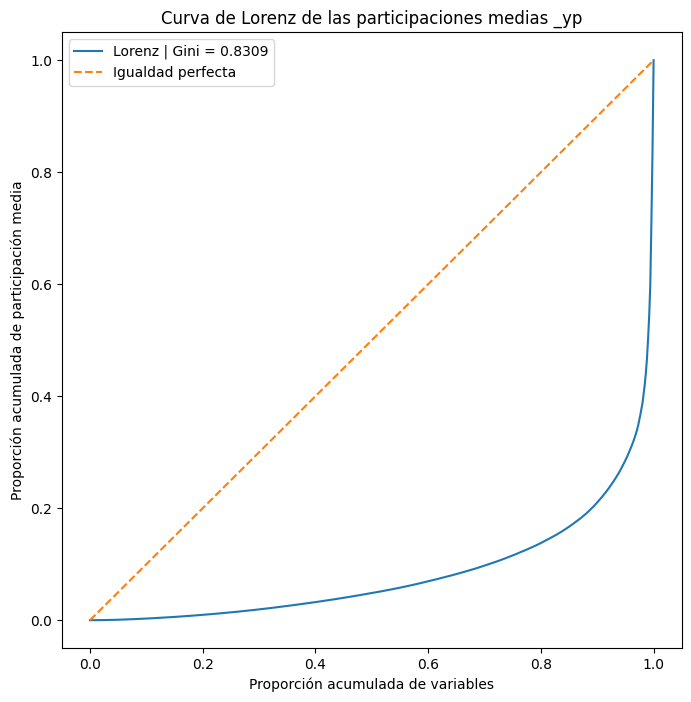

In [ ]:
plt.figure(figsize=(8, 8))
plt.plot(p, lorenz, label=f"Lorenz | Gini = {gini:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Igualdad perfecta")
plt.xlabel("Proporción acumulada de variables")
plt.ylabel("Proporción acumulada de participación media")
plt.title("Curva de Lorenz de las participaciones medias _yp")
plt.legend()
plt.show()

In [ ]:
# La distribución de las participaciones medias presenta un coeficiente de
# Gini de 0.8309, lo que evidencia una estructura fuertemente concentrada.
# Este resultado indica que una proporción reducida de las variables acumula
# una fracción considerable de la participación total, mientras que la mayoría
# mantiene niveles medios relativamente bajos. La elevada concentración observada
#  es consistente con la marcada asimetría positiva y leptocurtosis previamente
#  identificadas en la distribución.


##TOP 1%, 5%, 10%, 25%, 50%

In [ ]:
import numpy as np
import pandas as pd

yp_sorted = yp.sort_values(ascending=False)

tops = {}

for pct in [0.01, 0.05, 0.10, 0.25, 0.50]:
    n = max(1, int(np.ceil(len(yp_sorted) * pct)))
    tops[f"Top {int(pct*100)}%"] = {
        "variables": n,
        "participacion": yp_sorted.iloc[:n].sum(),
        "participacion_pct": yp_sorted.iloc[:n].sum() / yp_sorted.sum() * 100
    }

top_analysis = pd.DataFrame(tops).T
display(top_analysis)

,variables,participacion,participacion_pct
Top 1%,6.0,0.532876,53.287579
Top 5%,26.0,0.716410,71.641006
Top 10%,51.0,0.789703,78.970284
Top 25%,128.0,0.884714,88.471390
Top 50%,255.0,0.951451,95.145050


In [ ]:
for pct in [0.01, 0.05, 0.10]:
    n = max(1, int(np.ceil(len(yp_sorted) * pct)))

    print(f"\nTOP {int(pct*100)}% — {n} variables")
    display(
        yp_sorted.iloc[:n]
                 .rename("yp_mean")
                 .reset_index()
                 .rename(columns={"index": "variable"})
    )


TOP 1% — 6 variables


,variable,yp_mean
0,BTC_yp_mean,0.164137
1,ETH_yp_mean,0.126208
2,USDC_yp_mean,0.111296
3,SOL_yp_mean,0.055698
4,XRP_yp_mean,0.040472
5,FDUSD_yp_mean,0.035064



TOP 5% — 26 variables


,variable,yp_mean
0,BTC_yp_mean,0.164137
1,ETH_yp_mean,0.126208
2,USDC_yp_mean,0.111296
3,SOL_yp_mean,0.055698
4,XRP_yp_mean,0.040472
5,FDUSD_yp_mean,0.035064
6,DOGE_yp_mean,0.025772
7,BNB_yp_mean,0.020459
8,PEPE_yp_mean,0.016692
9,SUI_yp_mean,0.015872



TOP 10% — 51 variables


,variable,yp_mean
0,BTC_yp_mean,0.164137
1,ETH_yp_mean,0.126208
2,USDC_yp_mean,0.111296
3,SOL_yp_mean,0.055698
4,XRP_yp_mean,0.040472
5,FDUSD_yp_mean,0.035064
6,DOGE_yp_mean,0.025772
7,BNB_yp_mean,0.020459
8,PEPE_yp_mean,0.016692
9,SUI_yp_mean,0.015872


In [ ]:
top_acumulado = pd.DataFrame({
    "variable": yp_sorted.index,
    "yp_mean": yp_sorted.values,
})

top_acumulado["participacion_pct"] = (
    top_acumulado["yp_mean"] / top_acumulado["yp_mean"].sum() * 100
)

top_acumulado["participacion_acumulada_pct"] = (
    top_acumulado["participacion_pct"].cumsum()
)

display(top_acumulado.head(50))

,variable,yp_mean,participacion_pct,participacion_acumulada_pct
0,BTC_yp_mean,0.164137,16.413740,16.413740
1,ETH_yp_mean,0.126208,12.620796,29.034536
2,USDC_yp_mean,0.111296,11.129647,40.164185
3,SOL_yp_mean,0.055698,5.569820,45.734005
4,XRP_yp_mean,0.040472,4.047157,49.781162
5,FDUSD_yp_mean,0.035064,3.506412,53.287575
6,DOGE_yp_mean,0.025772,2.577192,55.864765
7,BNB_yp_mean,0.020459,2.045946,57.910709
8,PEPE_yp_mean,0.016692,1.669184,59.579895
9,SUI_yp_mean,0.015872,1.587201,61.167095


In [ ]:
# El análisis de las participaciones acumuladas confirma la elevada concentración
# observada mediante el coeficiente de Gini. Las seis variables con mayor
# participación media, equivalentes aproximadamente al 1.18% del total,
# concentran el 53.29% de la masa probabilística. Al considerar las
# 26 variables principales, esta participación asciende al 71.64%,
# mientras que las 51 variables superiores concentran el 78.97%.

# La concentración se mantiene al ampliar progresivamente el conjunto
# analizado: el 25% superior acumula el 88.47% de la participación total
# y el 50% superior alcanza el 95.15%. En consecuencia, la mitad inferior de
# las 510 variables representa únicamente el 4.85% de la participación media.

# Estos resultados evidencian una estructura transaccional marcadamente
# jerárquica, caracterizada por una pequeña cabeza de variables dominantes
# y una extensa cola de variables con participaciones individuales reducidas.
# La concentración se produce especialmente en el extremo superior de la
# distribución, siendo consistente con el elevado coeficiente de Gini,
# la fuerte asimetría positiva y la elevada curtosis observadas previamente.


In [ ]:
umbrales = [0.50, 0.80, 0.90, 0.95, 0.99]

acum = yp.sort_values(ascending=False).cumsum() / yp.sum()

resultado = []

for u in umbrales:
    n = (acum < u).sum() + 1
    resultado.append({
        "umbral": f"{int(u*100)}%",
        "variables_necesarias": n,
        "porcentaje_variables": n / len(yp) * 100,
        "participacion_alcanzada": acum.iloc[n-1] * 100
    })

resultado = pd.DataFrame(resultado)
display(resultado)

,umbral,variables_necesarias,porcentaje_variables,participacion_alcanzada
0,50%,6,1.176471,53.287579
1,80%,56,10.980392,80.010498
2,90%,150,29.411765,90.054451
3,95%,251,49.215686,95.005150
4,99%,406,79.607843,99.009003


In [ ]:
yp_sorted = yp.sort_values(ascending=False)

for u in umbrales:
    acum = yp_sorted.cumsum() / yp_sorted.sum()
    n = (acum < u).sum() + 1

    print(f"\nUMBRAL {int(u*100)}% — {n} variables")
    display(
        yp_sorted.iloc[:n]
                 .rename("yp_mean")
                 .reset_index()
                 .rename(columns={"index": "variable"})
    )


UMBRAL 50% — 6 variables


,variable,yp_mean
0,BTC_yp_mean,0.164137
1,ETH_yp_mean,0.126208
2,USDC_yp_mean,0.111296
3,SOL_yp_mean,0.055698
4,XRP_yp_mean,0.040472
5,FDUSD_yp_mean,0.035064



UMBRAL 80% — 56 variables


,variable,yp_mean
0,BTC_yp_mean,0.164137
1,ETH_yp_mean,0.126208
2,USDC_yp_mean,0.111296
3,SOL_yp_mean,0.055698
4,XRP_yp_mean,0.040472
5,FDUSD_yp_mean,0.035064
6,DOGE_yp_mean,0.025772
7,BNB_yp_mean,0.020459
8,PEPE_yp_mean,0.016692
9,SUI_yp_mean,0.015872



UMBRAL 90% — 150 variables


,variable,yp_mean
0,BTC_yp_mean,0.164137
1,ETH_yp_mean,0.126208
2,USDC_yp_mean,0.111296
3,SOL_yp_mean,0.055698
4,XRP_yp_mean,0.040472
...,...,...
145,JTO_yp_mean,0.000676
146,ANIME_yp_mean,0.000675
147,BFUSD_yp_mean,0.000668
148,PROVE_yp_mean,0.000661



UMBRAL 95% — 251 variables


,variable,yp_mean
0,BTC_yp_mean,0.164137
1,ETH_yp_mean,0.126208
2,USDC_yp_mean,0.111296
3,SOL_yp_mean,0.055698
4,XRP_yp_mean,0.040472
...,...,...
246,AEVO_yp_mean,0.000364
247,LUMIA_yp_mean,0.000363
248,SIGN_yp_mean,0.000357
249,GPS_yp_mean,0.000356



UMBRAL 99% — 406 variables


,variable,yp_mean
0,BTC_yp_mean,0.164137
1,ETH_yp_mean,0.126208
2,USDC_yp_mean,0.111296
3,SOL_yp_mean,0.055698
4,XRP_yp_mean,0.040472
...,...,...
401,RLC_yp_mean,0.000170
402,COS_yp_mean,0.000168
403,CHR_yp_mean,0.000167
404,FORTH_yp_mean,0.000165


#Reduccion dimensional segun entropia

In [ ]:
import numpy as np
import pandas as pd

p = yp / yp.sum()
N = len(p)

H = -(p[p > 0] * np.log(p[p > 0])).sum()
H_max = np.log(N)

resultados = pd.Series({
    "Variables nominales": N,
    "Entropía Shannon": H,
    "Entropía máxima": H_max,
    "Entropía normalizada": H / H_max,
    "N efectivo Shannon": np.exp(H),
    "HHI": np.sum(p ** 2),
    "N efectivo Simpson_HHI": 1 / np.sum(p ** 2)
})

display(resultados)

,0
Variables nominales,510.000000
Entropía Shannon,4.008575
Entropía máxima,6.234411
Entropía normalizada,0.642976
N efectivo Shannon,55.068367
HHI,0.064010
N efectivo Simpson_HHI,15.622677


In [ ]:
# El análisis de diversidad efectiva muestra que las 510 variables nominales
# representan un sistema mucho más concentrado de lo que su tamaño aparente sugiere.
# La entropía de Shannon alcanza 4.0086 frente a un máximo posible de 6.2344,
# equivalente al 64.3% de la entropía máxima.
# Al transformar esta medida en número efectivo de participantes, se obtiene
# un valor de 55.07, lo que indica que la distribución observada posee una
# diversidad equivalente a la de aproximadamente 55 variables igualmente ponderadas.

# La concentración se vuelve aún más evidente al utilizar el índice HHI. Su valor
# de 0.0640 implica un número efectivo de Simpson de apenas 15.62 participantes.
# Esta medida, al otorgar mayor peso a las probabilidades más elevadas, revela que
# la estructura dominante del sistema equivale a una distribución uniforme de
# aproximadamente 16 variables.

# En conjunto, los resultados muestran una marcada diferencia entre el número
# nominal de participantes y su relevancia efectiva. Mientras existen 510
# variables en el universo analizado, la diversidad informacional se reduce a unas
# 55 y la concentración dominante a unas 16. Esta estructura es consistente
# con los resultados previos de Gini, participación acumulada y umbrales de
# concentración, confirmando la existencia de una cabeza altamente concentrada
# acompañada por una extensa cola de variables con participaciones reducidas.


#Reduccion dentro del subconjunto relevante

In [ ]:
import numpy as np
import pandas as pd

yp55 = yp.nlargest(55)

p55 = yp55 / yp55.sum()
N55 = len(p55)

H55 = -(p55[p55 > 0] * np.log(p55[p55 > 0])).sum()
H55_max = np.log(N55)

gini55 = (
    np.abs(np.subtract.outer(p55.values, p55.values)).sum()
    / (2 * N55 * p55.mean())
)

resultados55 = pd.Series({
    "Variables nominales": N55,
    "Masa original capturada": yp55.sum() / yp.sum(),
    "Media": yp55.mean(),
    "Mediana": yp55.median(),
    "Varianza": yp55.var(),
    "Desviacion_estandar": yp55.std(),
    "Sesgo": yp55.skew(),
    "Kurtosis": yp55.kurt(),
    "Minimo": yp55.min(),
    "Q1": yp55.quantile(.25),
    "Q2_mediana": yp55.quantile(.50),
    "Q3": yp55.quantile(.75),
    "IQR": yp55.quantile(.75) - yp55.quantile(.25),
    "Maximo": yp55.max(),
    "Gini": gini55,
    "Entropia_Shannon": H55,
    "Entropia_maxima": H55_max,
    "Entropia_normalizada": H55 / H55_max,
    "N_efectivo_Shannon": np.exp(H55),
    "HHI": np.sum(p55 ** 2),
    "N_efectivo_Simpson_HHI": 1 / np.sum(p55 ** 2)
})

display(resultados55)

,0
Variables nominales,55.000000
Masa original capturada,0.798155
Media,0.014512
Mediana,0.003876
Varianza,0.000968
Desviacion_estandar,0.031111
Sesgo,3.631745
Kurtosis,13.366413
Minimo,0.001996
Q1,0.002689


In [ ]:
yp55_sorted = yp55.sort_values(ascending=False)

tops55 = {}

for pct in [0.01, 0.05, 0.10, 0.25, 0.50]:
    n = max(1, int(np.ceil(N55 * pct)))
    share = yp55_sorted.iloc[:n].sum() / yp55_sorted.sum()

    tops55[f"Top {int(pct*100)}%"] = {
        "variables": n,
        "participacion_pct": share * 100
    }

display(pd.DataFrame(tops55).T)

,variables,participacion_pct
Top 1%,1.0,20.564596
Top 5%,3.0,50.321274
Top 10%,6.0,66.763428
Top 25%,14.0,81.731880
Top 50%,28.0,90.734055


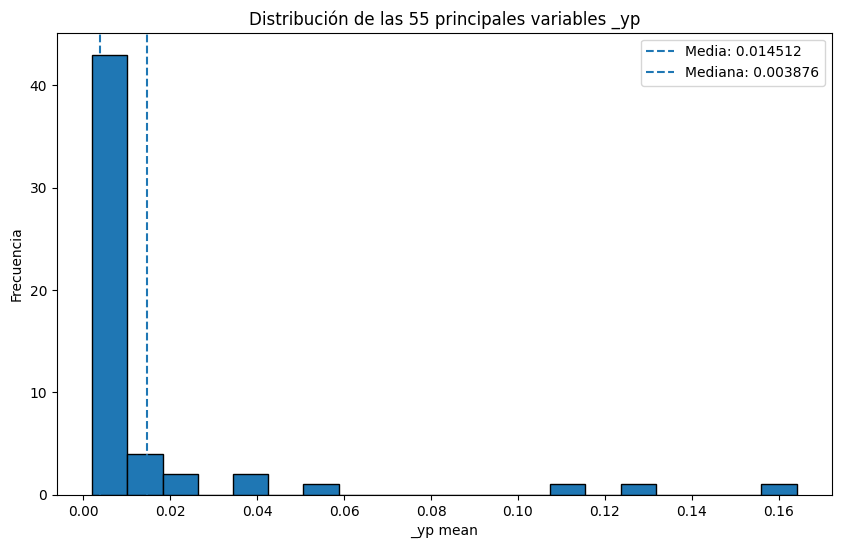

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(yp55, bins=20, edgecolor="black")
plt.axvline(yp55.mean(), linestyle="--", label=f"Media: {yp55.mean():.6f}")
plt.axvline(yp55.median(), linestyle="--", label=f"Mediana: {yp55.median():.6f}")
plt.xlabel("_yp mean")
plt.ylabel("Frecuencia")
plt.title("Distribución de las 55 principales variables _yp")
plt.legend()
plt.show()

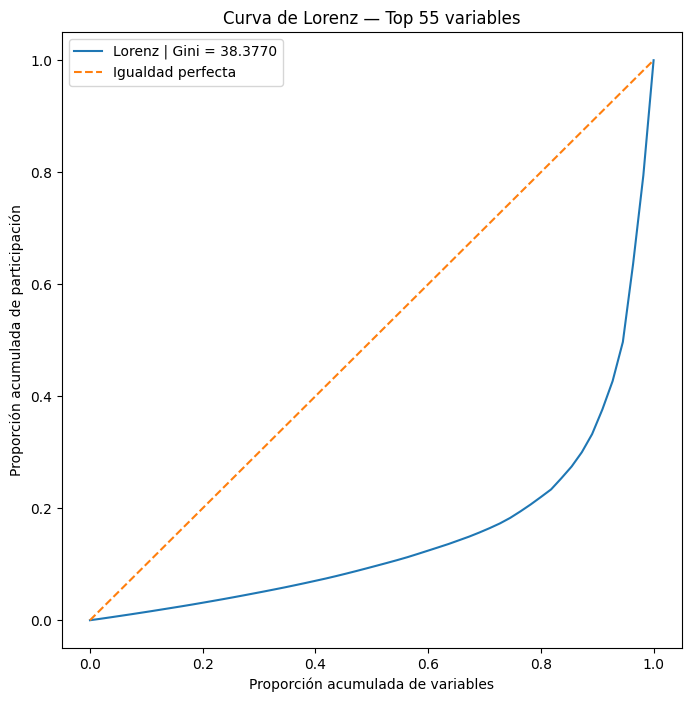

In [ ]:
x55 = np.sort(p55.values)

lorenz55 = np.insert(np.cumsum(x55), 0, 0)
poblacion55 = np.linspace(0, 1, len(lorenz55))

plt.figure(figsize=(8, 8))
plt.plot(poblacion55, lorenz55, label=f"Lorenz | Gini = {gini55:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Igualdad perfecta")
plt.xlabel("Proporción acumulada de variables")
plt.ylabel("Proporción acumulada de participación")
plt.title("Curva de Lorenz — Top 55 variables")
plt.legend()
plt.show()

#Analisis subconjuntos

In [ ]:
import numpy as np
import pandas as pd

yp_sorted = yp.sort_values(ascending=False)

def n_shannon(x):
    p = x / x.sum()
    return int(round(np.exp(-(p * np.log(p)).sum())))

def n_simpson(x):
    p = x / x.sum()
    return int(round(1 / np.sum(p**2)))

def n_masa(x, umbral=0.50):
    acum = x.cumsum() / x.sum()
    return int((acum < umbral).sum() + 1)

n_total = len(yp_sorted)
n_1 = n_shannon(yp_sorted)

s1 = yp_sorted.iloc[:n_1]
n_2 = n_shannon(s1)
n_3 = n_simpson(s1)
n_4 = n_masa(s1, 0.50)

jerarquia = pd.DataFrame({
    "nivel": [
        "Universo nominal",
        "Shannon efectivo global",
        "Shannon efectivo del núcleo",
        "Simpson efectivo del núcleo",
        "Variables para 50% del núcleo"
    ],
    "n_variables": [n_total, n_1, n_2, n_3, n_4]
})

display(jerarquia)

print(" → ".join(jerarquia["n_variables"].astype(str)))

,nivel,n_variables
0,Universo nominal,510
1,Shannon efectivo global,55
2,Shannon efectivo del núcleo,19
3,Simpson efectivo del núcleo,10
4,Variables para 50% del núcleo,3


510 → 55 → 19 → 10 → 3


In [ ]:
subconjuntos = {
    "Top Shannon global": n_1,
    "Top Shannon núcleo": n_2,
    "Top Simpson núcleo": n_3,
    "Top 50% núcleo": n_4
}

media_global = yp_sorted.mean()
ss_total = ((yp_sorted - media_global) ** 2).sum()

resultados_var = []

for nombre, n in subconjuntos.items():
    sub = yp_sorted.iloc[:n]
    resto = yp_sorted.iloc[n:]

    ss_sub = ((sub - media_global) ** 2).sum()
    ss_resto = ((resto - media_global) ** 2).sum()

    resultados_var.append({
        "subconjunto": nombre,
        "n": n,
        "var_sub": sub.var(),
        "var_resto": resto.var(),
        "ratio_var": sub.var() / resto.var(),
        "var_total_pct_sub": ss_sub / ss_total * 100,
        "var_total_pct_resto": ss_resto / ss_total * 100
    })

varianza_subconjuntos = pd.DataFrame(resultados_var)

display(varianza_subconjuntos)

,subconjunto,n,var_sub,var_resto,ratio_var,var_total_pct_sub,var_total_pct_resto
0,Top Shannon global,55,0.000968,1.529149e-07,6329.812826,98.200211,1.799785
1,Top Shannon núcleo,19,0.002157,7.028803e-07,3068.400365,98.070976,1.929017
2,Top Simpson núcleo,10,0.002825,1.740350e-06,1623.259636,97.470520,2.529482
3,Top 50% núcleo,3,0.000742,1.590297e-05,46.670099,86.533447,13.466558


#validacion temporal

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WINDOW = "30D"

cols = [c for c in dfmacro.columns if c.endswith("_yp_mean")]

d = dfmacro.set_index("bar_end")[cols].sort_index()

periodos = d.resample(WINDOW).mean().dropna(how="all")

In [ ]:
def gini(x):
    x = np.sort(np.asarray(x))
    x = x[np.isfinite(x) & (x >= 0)]
    n = len(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) / (n * x.sum())) - (n + 1) / n

def metricas(x):
    x = x.dropna().sort_values(ascending=False)
    p = x / x.sum()
    n = len(x)

    H = -(p[p > 0] * np.log(p[p > 0])).sum()

    r = {
        "n": n,
        "gini": gini(x),
        "shannon": H,
        "shannon_norm": H / np.log(n),
        "n_eff_shannon": np.exp(H),
        "hhi": np.sum(p**2),
        "n_eff_simpson": 1 / np.sum(p**2)
    }

    for pct in [.01, .05, .10, .25, .50]:
        k = max(1, int(np.ceil(n * pct)))
        r[f"top_{int(pct*100)}_share"] = p.iloc[:k].sum()

    acum = p.cumsum()

    for u in [.50, .80, .90, .95, .99]:
        r[f"n_{int(u*100)}_mass"] = int((acum < u).sum() + 1)

    return pd.Series(r)

In [ ]:
estabilidad = periodos.apply(metricas, axis=1)

display(estabilidad)

,n,gini,shannon,shannon_norm,n_eff_shannon,hhi,n_eff_simpson,top_1_share,top_5_share,top_10_share,top_25_share,top_50_share,n_50_mass,n_80_mass,n_90_mass,n_95_mass,n_99_mass
bar_end,,,,,,,,,,,,,,,,,
2024-11-01 00:00:00+00:00,510.0,0.869448,4.028128,0.646112,56.155670,0.053071,18.842648,0.474790,0.716175,0.809425,0.922907,0.979333,7.0,48.0,103.0,174.0,303.0
2024-12-01 00:00:00+00:00,510.0,0.842333,4.306621,0.690782,74.189346,0.038500,25.974308,0.413390,0.657565,0.766133,0.903727,0.973264,10.0,64.0,125.0,193.0,322.0
2024-12-31 00:00:00+00:00,510.0,0.873646,4.014433,0.643915,55.391903,0.049837,20.065382,0.478265,0.726579,0.819612,0.926306,0.980153,7.0,45.0,99.0,168.0,303.0
2025-01-30 00:00:00+00:00,510.0,0.881647,3.900481,0.625638,49.426235,0.058785,17.011158,0.510764,0.746386,0.834882,0.931771,0.980740,6.0,39.0,92.0,160.0,303.0
2025-03-01 00:00:00+00:00,510.0,0.881131,3.820535,0.612814,45.628632,0.067842,14.740214,0.547600,0.755512,0.829352,0.929128,0.979922,6.0,40.0,95.0,165.0,309.0
2025-03-31 00:00:00+00:00,510.0,0.869628,3.823684,0.613319,45.772541,0.074562,13.411611,0.555321,0.738419,0.812007,0.915125,0.975902,5.0,46.0,112.0,183.0,320.0
2025-04-30 00:00:00+00:00,510.0,0.877736,3.821567,0.612980,45.675728,0.070831,14.118014,0.533228,0.744516,0.823702,0.925223,0.978958,5.0,43.0,99.0,170.0,310.0
2025-05-30 00:00:00+00:00,510.0,0.886804,3.701011,0.593643,40.488235,0.078503,12.738296,0.576380,0.755368,0.834663,0.933539,0.981239,4.0,39.0,90.0,156.0,304.0
2025-06-29 00:00:00+00:00,510.0,0.880952,3.828348,0.614067,45.986507,0.064481,15.508547,0.543297,0.754923,0.840941,0.927106,0.978019,5.0,37.0,95.0,171.0,313.0


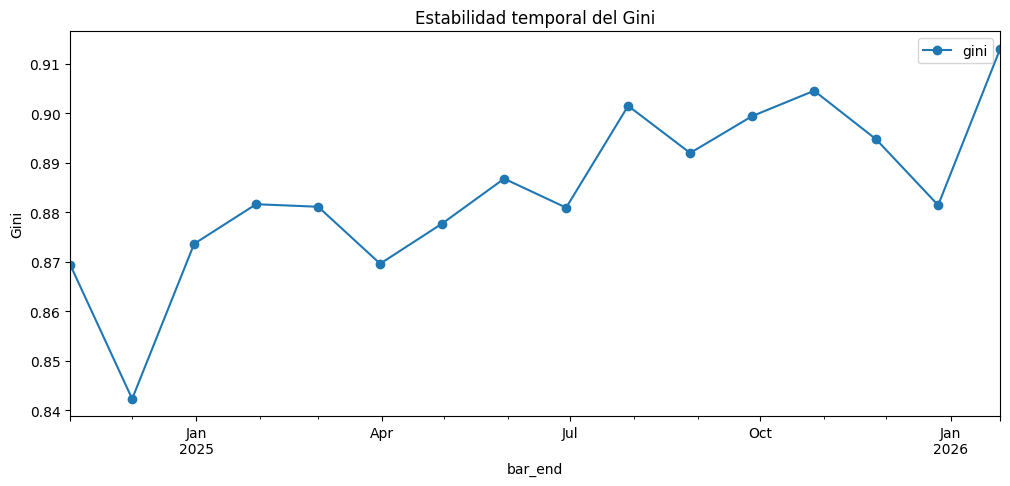

In [ ]:
estabilidad[["gini"]].plot(figsize=(12, 5), marker="o")
plt.title("Estabilidad temporal del Gini")
plt.ylabel("Gini")
plt.show()

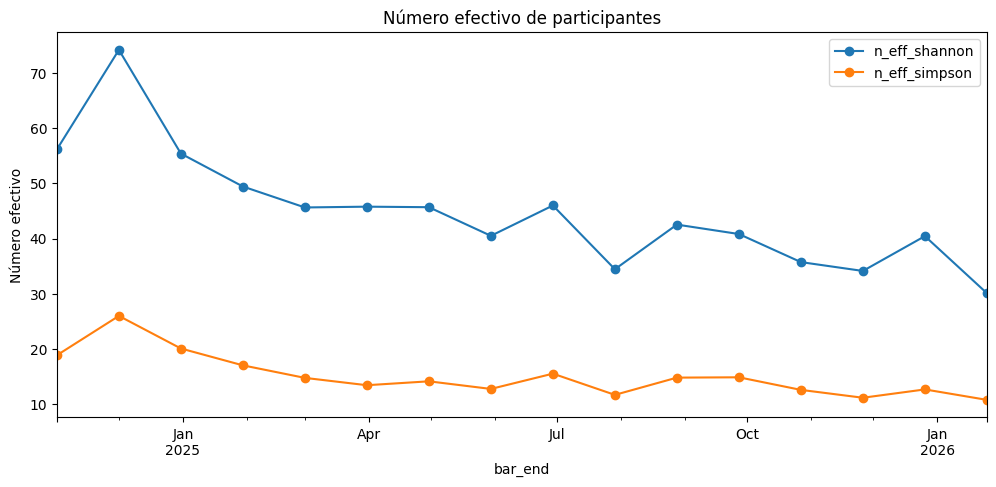

In [ ]:
estabilidad[["n_eff_shannon", "n_eff_simpson"]].plot(figsize=(12, 5), marker="o")
plt.title("Número efectivo de participantes")
plt.ylabel("Número efectivo")
plt.show()

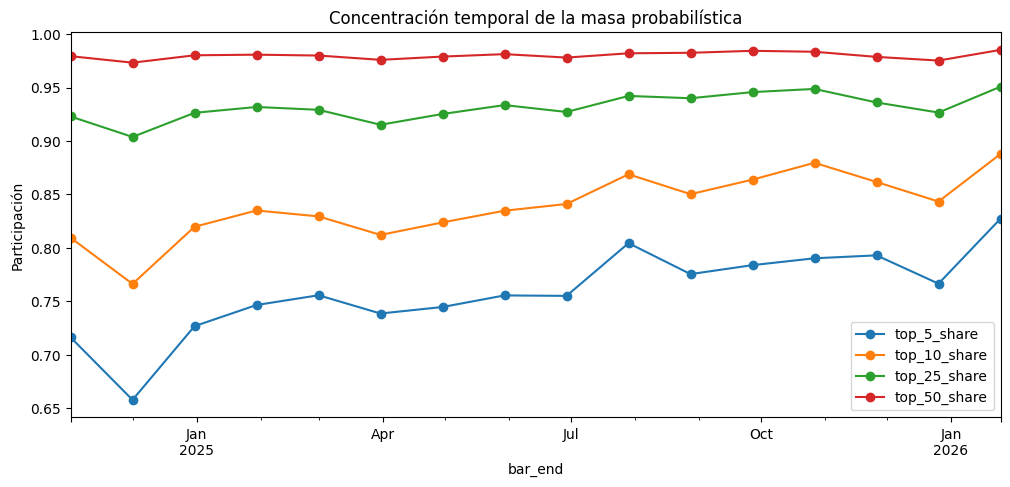

In [ ]:
estabilidad[
    ["top_5_share", "top_10_share", "top_25_share", "top_50_share"]
].plot(figsize=(12, 5), marker="o")

plt.title("Concentración temporal de la masa probabilística")
plt.ylabel("Participación")
plt.show()

#Analisis de Retencion y Jaccard


In [ ]:
TOP_PCT = 0.05
k = int(np.ceil(periodos.shape[1] * TOP_PCT))

top5 = {
    fecha: set(row.nlargest(k).index)
    for fecha, row in periodos.iterrows()
}

rows = []
fechas = list(top5)

for i in range(1, len(fechas)):
    prev, curr = top5[fechas[i - 1]], top5[fechas[i]]
    inter = prev & curr
    union = prev | curr

    rows.append({
        "fecha_anterior": fechas[i - 1],
        "fecha_actual": fechas[i],
        "n_top": k,
        "coincidentes": len(inter),
        "retencion": len(inter) / len(prev),
        "jaccard": len(inter) / len(union),
        "entradas": len(curr - prev),
        "salidas": len(prev - curr)
    })

top5_estabilidad = pd.DataFrame(rows)

display(top5_estabilidad)

,fecha_anterior,fecha_actual,n_top,coincidentes,retencion,jaccard,entradas,salidas
0,2024-11-01 00:00:00+00:00,2024-12-01 00:00:00+00:00,26,19,0.730769,0.575758,7,7
1,2024-12-01 00:00:00+00:00,2024-12-31 00:00:00+00:00,26,20,0.769231,0.625000,6,6
2,2024-12-31 00:00:00+00:00,2025-01-30 00:00:00+00:00,26,18,0.692308,0.529412,8,8
3,2025-01-30 00:00:00+00:00,2025-03-01 00:00:00+00:00,26,21,0.807692,0.677419,5,5
4,2025-03-01 00:00:00+00:00,2025-03-31 00:00:00+00:00,26,19,0.730769,0.575758,7,7
5,2025-03-31 00:00:00+00:00,2025-04-30 00:00:00+00:00,26,19,0.730769,0.575758,7,7
6,2025-04-30 00:00:00+00:00,2025-05-30 00:00:00+00:00,26,20,0.769231,0.625000,6,6
7,2025-05-30 00:00:00+00:00,2025-06-29 00:00:00+00:00,26,19,0.730769,0.575758,7,7
8,2025-06-29 00:00:00+00:00,2025-07-29 00:00:00+00:00,26,21,0.807692,0.677419,5,5
9,2025-07-29 00:00:00+00:00,2025-08-28 00:00:00+00:00,26,16,0.615385,0.444444,10,10


In [ ]:
display(
    top5_estabilidad[
        ["coincidentes", "retencion", "jaccard", "entradas", "salidas"]
    ].describe()
)

,coincidentes,retencion,jaccard,entradas,salidas
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,18.733333,0.720513,0.567206,7.266667,7.266667
std,1.791514,0.068904,0.081285,1.791514,1.791514
min,15.000000,0.576923,0.405405,5.000000,5.000000
25%,18.500000,0.711538,0.552585,6.000000,6.000000
50%,19.000000,0.730769,0.575758,7.000000,7.000000
75%,20.000000,0.769231,0.625000,7.500000,7.500000
max,21.000000,0.807692,0.677419,11.000000,11.000000


In [ ]:
print(f"Retención media: {top5_estabilidad['retencion'].mean():.2%}")
print(f"Jaccard medio:   {top5_estabilidad['jaccard'].mean():.2%}")
print(f"Retención mínima: {top5_estabilidad['retencion'].min():.2%}")
print(f"Retención máxima: {top5_estabilidad['retencion'].max():.2%}")

Retención media: 72.05%
Jaccard medio:   56.72%
Retención mínima: 57.69%
Retención máxima: 80.77%


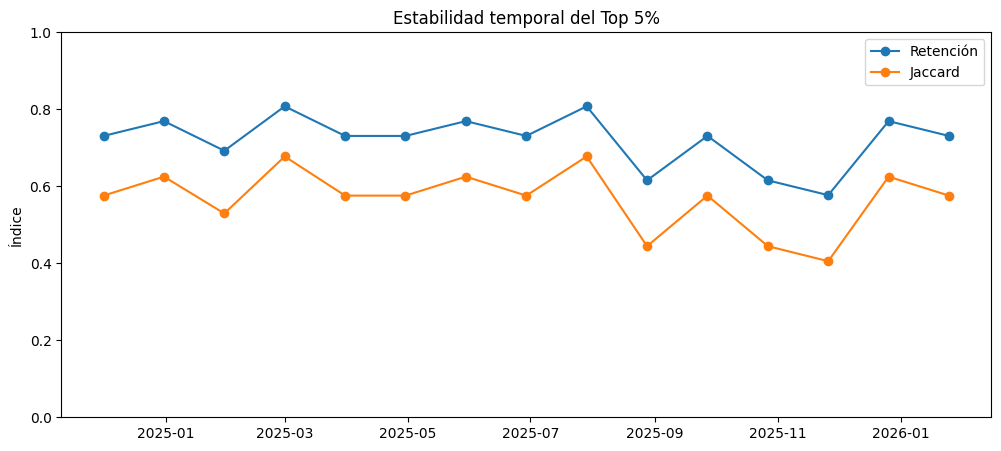

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    top5_estabilidad["fecha_actual"],
    top5_estabilidad["retencion"],
    marker="o",
    label="Retención"
)

plt.plot(
    top5_estabilidad["fecha_actual"],
    top5_estabilidad["jaccard"],
    marker="o",
    label="Jaccard"
)

plt.ylim(0, 1)
plt.ylabel("Índice")
plt.title("Estabilidad temporal del Top 5%")
plt.legend()
plt.show()

In [ ]:
frecuencia_top5 = (
    pd.Series(
        [activo for grupo in top5.values() for activo in grupo]
    )
    .value_counts()
    .rename("apariciones")
    .to_frame()
)

frecuencia_top5["pct_periodos"] = (
    frecuencia_top5["apariciones"] / len(top5) * 100
)

display(frecuencia_top5.head(50))

,apariciones,pct_periodos
FDUSD_yp_mean,16,100.00
XRP_yp_mean,16,100.00
ETH_yp_mean,16,100.00
BNB_yp_mean,16,100.00
USDC_yp_mean,16,100.00
SUI_yp_mean,16,100.00
BTC_yp_mean,16,100.00
DOGE_yp_mean,16,100.00
SOL_yp_mean,16,100.00
PEPE_yp_mean,15,93.75


In [ ]:
persistentes = frecuencia_top5[
    frecuencia_top5["pct_periodos"] >= 80
]

display(persistentes)

,apariciones,pct_periodos
FDUSD_yp_mean,16,100.00
XRP_yp_mean,16,100.00
ETH_yp_mean,16,100.00
BNB_yp_mean,16,100.00
USDC_yp_mean,16,100.00
SUI_yp_mean,16,100.00
BTC_yp_mean,16,100.00
DOGE_yp_mean,16,100.00
SOL_yp_mean,16,100.00
PEPE_yp_mean,15,93.75


El análisis evidencia una estructura fuertemente jerárquica del mercado. A pesar de considerar 510 variables nominales, la diversidad efectiva se reduce a aproximadamente 55 participantes según Shannon y a 16 según Simpson, mientras que la mayor parte de la dispersión transversal se concentra en un subconjunto aún menor. Los 55 activos principales explican aproximadamente el 98.2% de la suma de cuadrados respecto de la media global, y los diez principales conservan cerca del 97.5%. Paralelamente, el 50% inferior del universo concentra únicamente el 4.85% de la masa probabilística media.

El análisis de estabilidad temporal del Top 5% muestra una retención media mensual del 72.05% y un índice de Jaccard medio del 56.72%. En promedio, aproximadamente 19 de las 26 variables dominantes permanecen dentro del grupo entre períodos consecutivos, mientras alrededor de siete son reemplazadas. Esto indica que la elevada concentración del mercado es estructuralmente persistente, aunque la identidad de los participantes que integran el núcleo dominante presenta una rotación significativa. En consecuencia, una representación dimensional eficiente debería combinar un núcleo de participantes persistentes con un componente dinámico capaz de capturar cambios temporales en la composición del Top 5%.

#visuales

In [9]:
columnas_eth = [
    columna for columna in dfmacro.columns
    if columna.upper().startswith("BTC")
]

print(f"Total de columnas: {len(columnas_eth)}")
print(columnas_eth)

dfmacro[columnas_eth].head(10)

Total de columnas: 6
['BTCUSDT_mean', 'BTCUSDT_max', 'BTCUSDT_min', 'BTC_yp_mean', 'BTC_yp_max', 'BTC_yp_min']


,BTCUSDT_mean,BTCUSDT_max,BTCUSDT_min,BTC_yp_mean,BTC_yp_max,BTC_yp_min
0,69703.523438,70461.992188,69016.828125,0.250273,0.448915,0.114741
1,69581.703125,70212.117188,69084.007812,0.222909,0.489944,0.074595
2,70404.140625,71505.937500,69368.117188,0.299679,0.455309,0.134312
3,69304.187500,69586.007812,68880.000000,0.236873,0.460905,0.072465
4,69636.281250,69896.007812,69487.976562,0.178044,0.532383,0.072805
5,69645.843750,69824.890625,69432.953125,0.163368,0.361750,0.073776
6,69430.343750,69679.992188,69086.007812,0.176884,0.387115,0.051412
7,69431.156250,69564.000000,69168.632812,0.150579,0.548322,0.051154
8,68710.031250,69374.742188,68088.343750,0.243677,0.628481,0.097946
9,68451.101562,68732.210938,68206.000000,0.201611,0.434722,0.071734


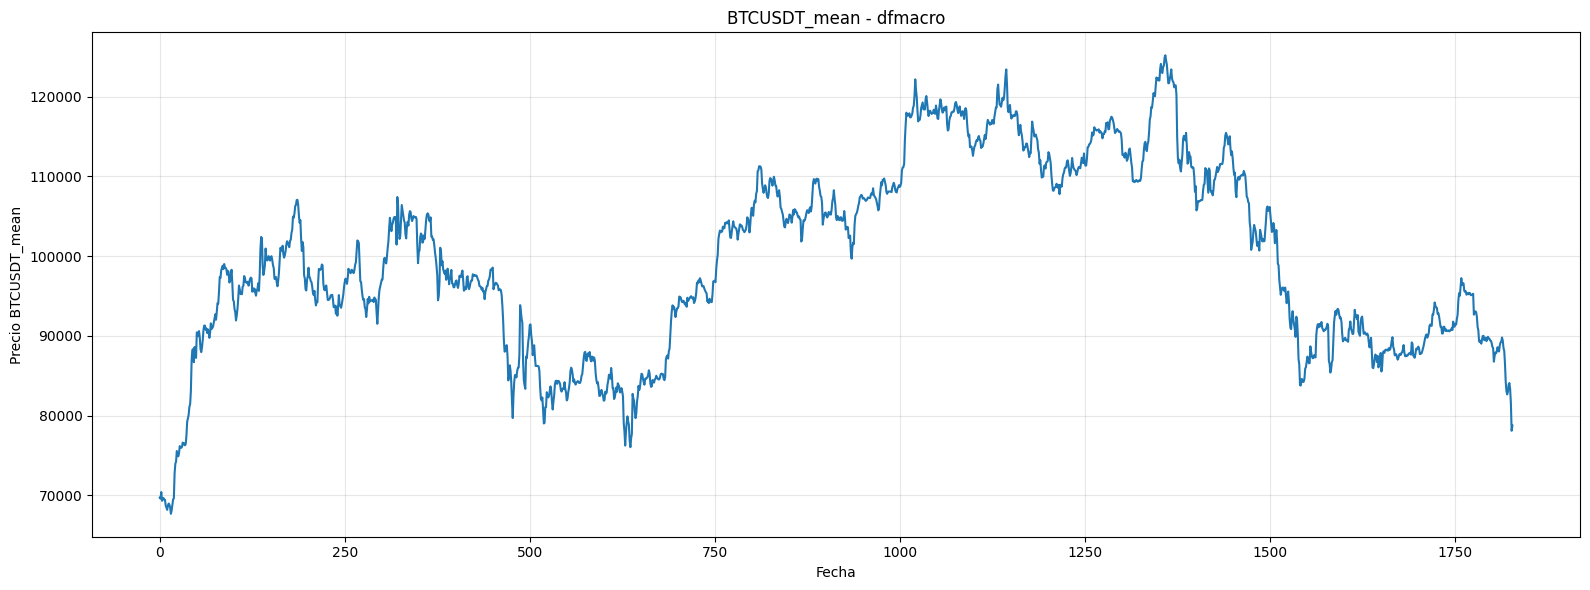

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
plt.plot(dfmacro.index, dfmacro["BTCUSDT_mean"])
plt.title("BTCUSDT_mean - dfmacro")
plt.xlabel("Fecha")
plt.ylabel("Precio BTCUSDT_mean")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# plt.figure(figsize=(16, 6))
# plt.plot(dfmacro.index, dfmacro["BTC_yp_mean"])
# plt.title("BTC_yp_mean - dfmacro")
# plt.xlabel("Fecha")
# plt.ylabel("Precio BTC_yp_mean")
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()


In [16]:
dfmacro.loc[[dfmacro.index[0], dfmacro.index[609], dfmacro.index[1218], dfmacro.index[-1]], "bar_end"]

,bar_end
0,2024-11-01 00:00:00+00:00
609,2025-04-02 06:00:00+00:00
1218,2025-09-01 12:00:00+00:00
1828,2026-02-01 00:00:00+00:00
